# Ex.No.5 - Skin Colour Detection

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 07/03/2026_

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from imageio import imread
import random

%matplotlib inline

In [4]:
# Paths for the Face and Mask
face_dir = r"D:\VI\IP & CV\Lab Experiments\Inputs\FacePhoto"
mask_dir = r"D:\VI\IP & CV\Lab Experiments\Inputs\GroundT_FacePhoto"

In [5]:
# Function to load image
def load_images(image_folder, mask_folder):
    images = []
    masks = []
    names = []

    image_files = os.listdir(image_folder)
    mask_files = os.listdir(mask_folder)

    for img_file in image_files:
        name = os.path.splitext(img_file)[0]   # filename without extension

        # find corresponding mask
        for mask_file in mask_files:
            mask_name = os.path.splitext(mask_file)[0]
            if name == mask_name:
                img_path = os.path.join(image_folder, img_file)
                mask_path = os.path.join(mask_folder, mask_file)

                image = imread(img_path)
                mask = imread(mask_path)

                images.append(image)
                masks.append(mask)
                names.append(img_file)
                break

    return images, masks, names

In [8]:
# Function to Extract Skin
def extract_skin(image, mask):
    mask_rgb = mask[:, :, :3]

    # white pixels in mask represent skin
    skin_pixels = np.all(mask_rgb == [255,255,255], axis=-1)
    skin_image = np.zeros_like(image)
    skin_image[skin_pixels] = image[skin_pixels]

    return skin_image, skin_pixels

In [11]:
# Function to display output
def display_results(image, mask, skin_image, name):
    plt.figure(figsize=(12,8))

    plt.subplot(2,2,1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(mask)
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(image)
    plt.imshow(mask, alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(skin_image)
    plt.title("Extracted Skin")
    plt.axis("off")

    plt.suptitle(name)
    plt.show()

In [12]:
# Load Dataset
images, masks, names = load_images(face_dir, mask_dir)
print("Number of Face Images Loaded:", len(images))

C:\Users\Monish\AppData\Local\Temp\ipykernel_2920\2608569398.py:26: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread(img_path)
C:\Users\Monish\AppData\Local\Temp\ipykernel_2920\2608569398.py:27: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask = imread(mask_path)


Number of Face Images Loaded: 32


Image: chenhao0017me9.jpg
Skin Pixels: 92564
Skin Percentage: 15.24%
--------------------------------


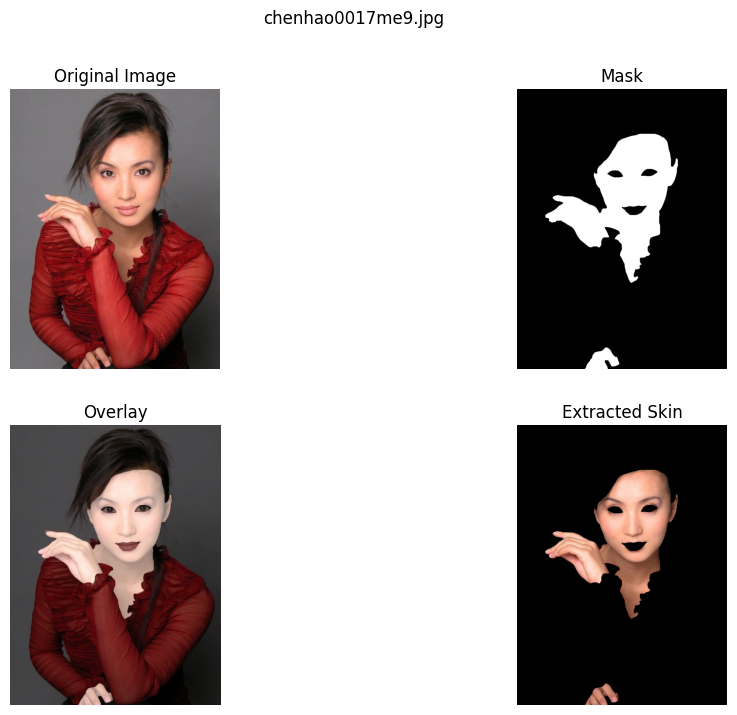

Image: josh-hartnett-Poster-thumb.jpg
Skin Pixels: 47359
Skin Percentage: 37.00%
--------------------------------


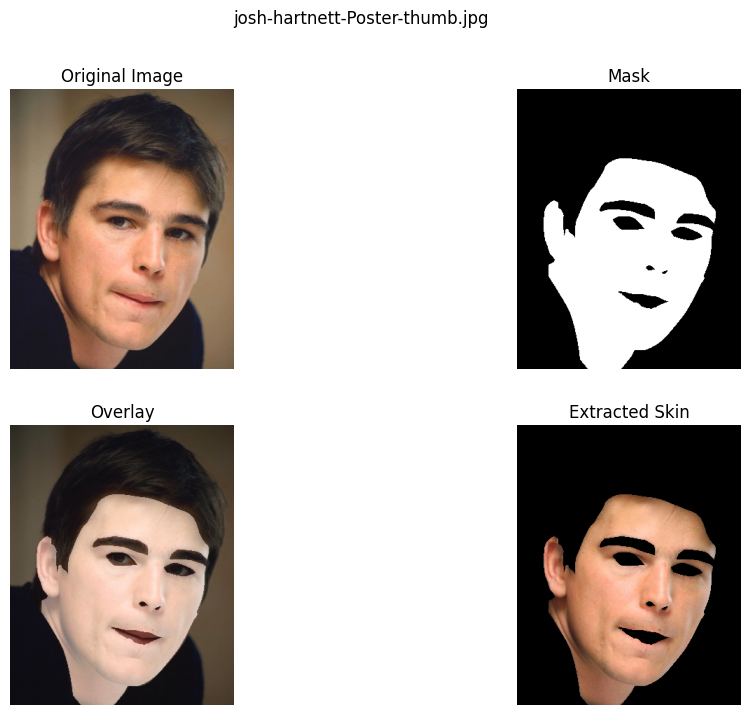

In [43]:
# Process Images
for i in range(len(images)):
    k = random.randint(0, len(images)-1)
    image = images[k]
    mask = masks[k]
    name = names[k]

    skin_image, skin_pixels = extract_skin(image, mask)

    total_pixels = skin_pixels.size
    skin_count = np.sum(skin_pixels)

    skin_percentage = (skin_count / total_pixels) * 100

    print("Image:", name)
    print("Skin Pixels:", skin_count)
    print("Skin Percentage: %.2f%%" % skin_percentage)
    print("--------------------------------")

    display_results(image, mask, skin_image, name)

    # show only first 3 images
    if i == 1:
        break